# F4 — Análisis de resultados

## Pregunta de investigación

¿Qué factores —rubro económico, región y tipo de proceso— se asocian a multas de mayor magnitud en UTA?

## Objetivo

Analizar la magnitud de las multas de los procedimientos sancionatorios de la Superintendencia del Medio Ambiente (SMA), considerando su relación con el rubro económico, la región y el tipo de proceso.

La unidad de análisis corresponde al procedimiento sancionatorio identificado mediante `ProcesoSancionId`.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permite importar funciones desde src/
RAIZ_PROYECTO = Path.cwd().parent
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.procesamiento import construir_universo_procedimientos

print("Directorio actual:", Path.cwd())
print("Raíz del proyecto:", RAIZ_PROYECTO)
print("src existe:", (RAIZ_PROYECTO / "src").exists())

Directorio actual: c:\Users\hernan.saavedra\Documents\proyecto_sma\F4
Raíz del proyecto: c:\Users\hernan.saavedra\Documents\proyecto_sma
src existe: True


In [2]:
RUTA_DATOS = (
    RAIZ_PROYECTO
    / "data"
    / "processed"
    / "sancionatorios_procesados.csv"
)

df = pd.read_csv(RUTA_DATOS)

print("Registros cargados:", len(df))
print("Columnas:", len(df.columns))

Registros cargados: 984
Columnas: 20


In [3]:
universo = construir_universo_procedimientos(df)

print("Registros originales:", len(df))
print("Procedimientos del universo analítico:", len(universo))
print("IDs únicos:", universo["ProcesoSancionId"].nunique())

Registros originales: 984
Procedimientos del universo analítico: 963
IDs únicos: 963


In [4]:
universo["MultaTotalUTA"].describe()

count      963.000000
mean       158.332596
std        916.332647
min          0.200000
25%          1.950000
50%          7.100000
75%         35.500000
max      14745.000000
Name: MultaTotalUTA, dtype: float64

In [5]:
print("Multas nulas:", universo["MultaTotalUTA"].isna().sum())
print("Multas iguales a cero:", (universo["MultaTotalUTA"] == 0).sum())

Multas nulas: 0
Multas iguales a cero: 0


## 6. Análisis por rubro económico

Se analiza la distribución de `MultaTotalUTA` según `CategoriaEconomicaNombre`.

Debido a la asimetría de la variable de multa, se utiliza la mediana como medida descriptiva principal y los cuartiles para representar la dispersión. Los valores extremos se mantienen, ya que corresponden a sanciones observadas en el conjunto de datos.

In [6]:
resumen_rubro = (
    universo
    .groupby("CategoriaEconomicaNombre")["MultaTotalUTA"]
    .agg(
        cantidad="count",
        mediana="median",
        promedio="mean",
        minimo="min",
        maximo="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .sort_values("mediana", ascending=False)
)

resumen_rubro

,cantidad,mediana,promedio,minimo,maximo,q1,q3
CategoriaEconomicaNombre,,,,,,,
Minería,40,443.0,2024.602500,1.70,14745.0,48.000,2403.750
Energía,17,345.0,913.829412,1.00,8640.4,76.000,809.000
Infraestructura Hidráulica,2,135.0,135.000000,20.00,250.0,77.500,192.500
Saneamiento Ambiental,27,91.0,180.533333,1.10,1030.0,23.000,234.700
Infraestructura de Transporte,10,52.0,180.450000,1.20,1006.0,8.275,119.300
Agroindustrias,75,29.0,164.195333,0.25,3433.0,9.900,75.550
Vivienda e Inmobiliarios,150,27.0,60.972667,1.00,2035.0,3.775,62.000
Infraestructura Portuaria,8,21.6,187.712500,1.10,1237.0,4.150,93.750
Transportes y almacenajes,3,14.0,71.100000,1.30,198.0,7.650,106.000


C:\Users\hernan.saavedra\AppData\Local\Temp\ipykernel_8776\2113141090.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


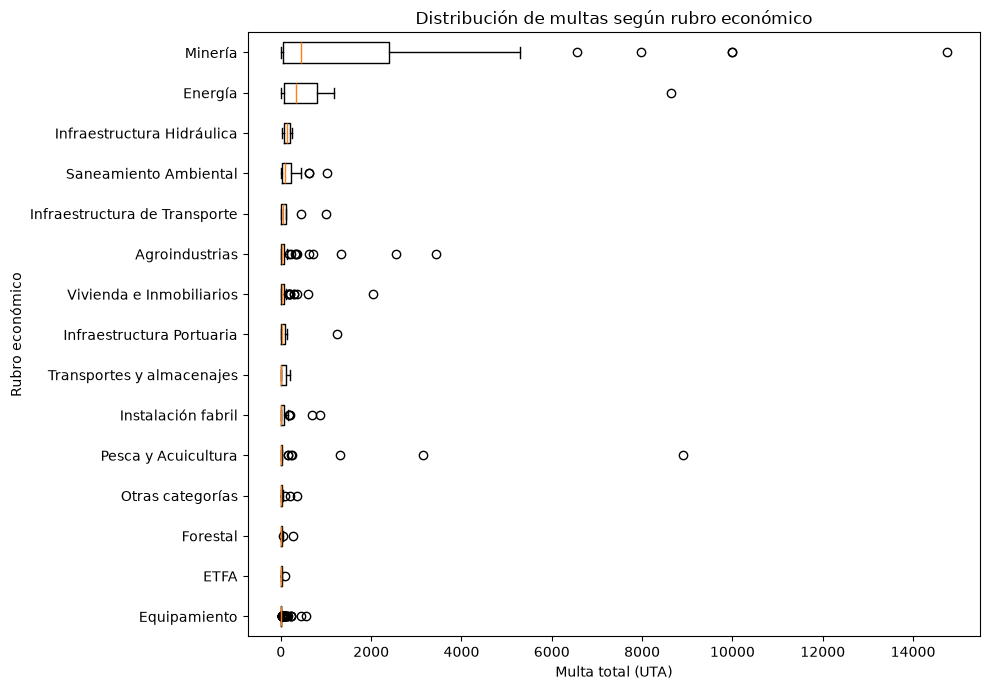

In [7]:
orden_rubro = (
    universo
    .groupby("CategoriaEconomicaNombre")["MultaTotalUTA"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(10, 7))

plt.boxplot(
    [
        universo.loc[
            universo["CategoriaEconomicaNombre"] == categoria,
            "MultaTotalUTA"
        ]
        for categoria in orden_rubro
    ],
    vert=False,
    tick_labels=orden_rubro
)

plt.xlabel("Multa total (UTA)")
plt.ylabel("Rubro económico")
plt.title("Distribución de multas según rubro económico")
plt.tight_layout()
plt.show()

### Visualización en escala logarítmica

La distribución de `MultaTotalUTA` presenta una marcada asimetría positiva y valores extremos de gran magnitud. Para facilitar la comparación visual entre categorías, se utiliza una escala logarítmica en el eje de las multas. Esta transformación se utiliza únicamente para la representación gráfica y no modifica los valores originales del conjunto de datos.

C:\Users\hernan.saavedra\AppData\Local\Temp\ipykernel_8776\3471795565.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


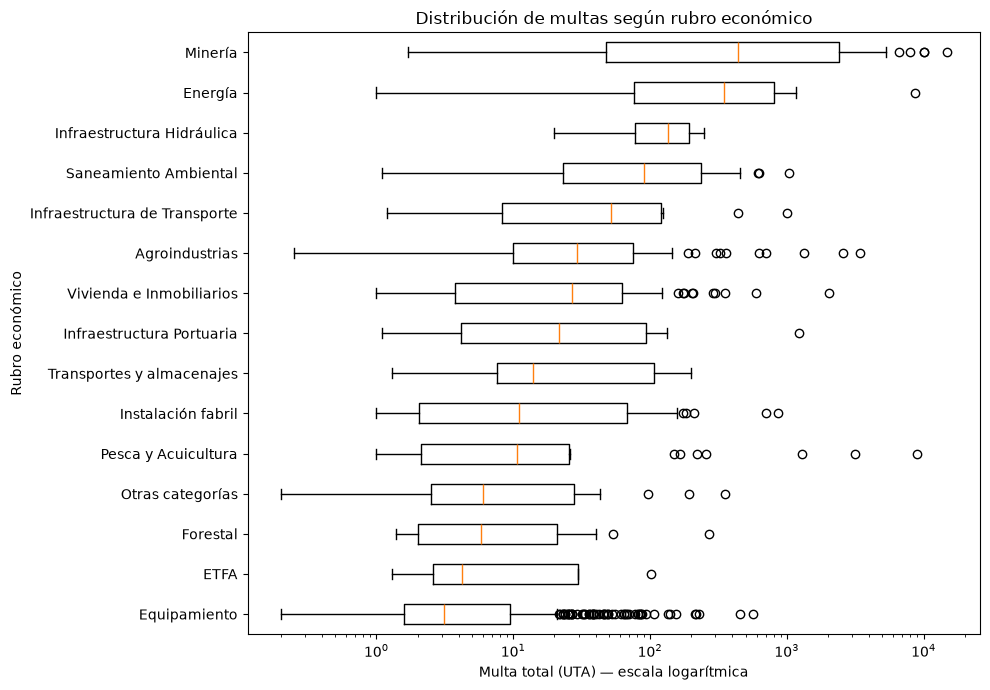

In [8]:
plt.figure(figsize=(10, 7))

plt.boxplot(
    [
        universo.loc[
            universo["CategoriaEconomicaNombre"] == categoria,
            "MultaTotalUTA"
        ]
        for categoria in orden_rubro
    ],
    vert=False,
    tick_labels=orden_rubro
)

plt.xscale("log")

plt.xlabel("Multa total (UTA) — escala logarítmica")
plt.ylabel("Rubro económico")
plt.title("Distribución de multas según rubro económico")
plt.tight_layout()
plt.show()

C:\Users\hernan.saavedra\AppData\Local\Temp\ipykernel_8776\2294155524.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


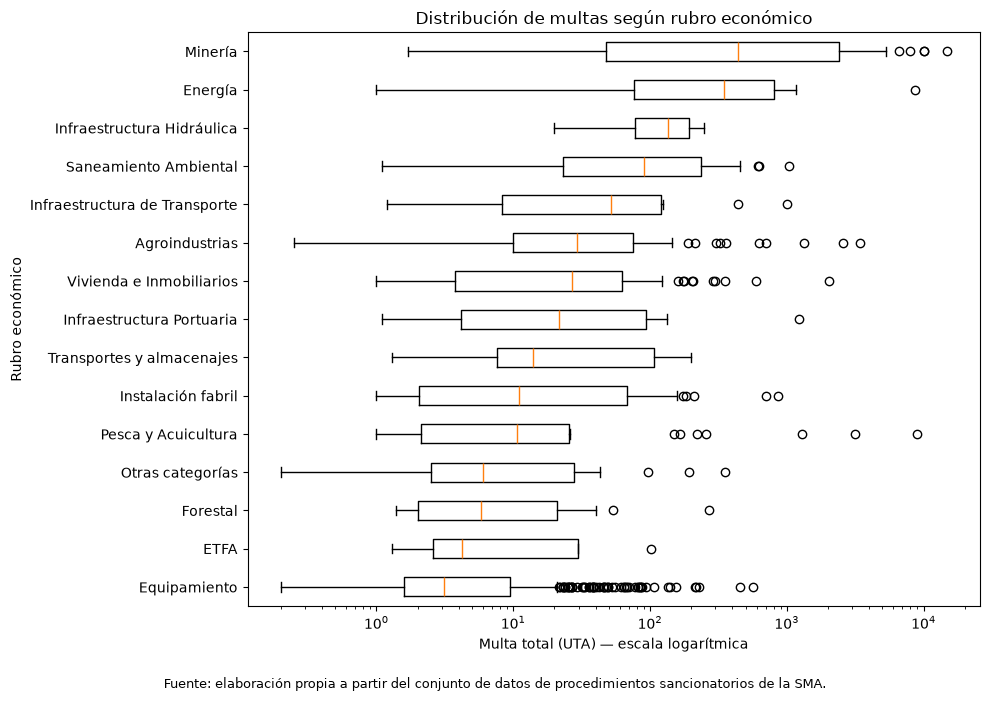

In [9]:
plt.figure(figsize=(10, 7))

plt.boxplot(
    [
        universo.loc[
            universo["CategoriaEconomicaNombre"] == categoria,
            "MultaTotalUTA"
        ]
        for categoria in orden_rubro
    ],
    vert=False,
    tick_labels=orden_rubro
)

plt.xscale("log")

plt.xlabel("Multa total (UTA) — escala logarítmica")
plt.ylabel("Rubro económico")
plt.title("Distribución de multas según rubro económico")

plt.figtext(
    0.5,
    0.01,
    "Fuente: elaboración propia a partir del conjunto de datos de procedimientos sancionatorios de la SMA.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [10]:
resumen_rubro[["cantidad", "mediana", "q1", "q3"]]

,cantidad,mediana,q1,q3
CategoriaEconomicaNombre,,,,
Minería,40,443.0,48.000,2403.750
Energía,17,345.0,76.000,809.000
Infraestructura Hidráulica,2,135.0,77.500,192.500
Saneamiento Ambiental,27,91.0,23.000,234.700
Infraestructura de Transporte,10,52.0,8.275,119.300
Agroindustrias,75,29.0,9.900,75.550
Vivienda e Inmobiliarios,150,27.0,3.775,62.000
Infraestructura Portuaria,8,21.6,4.150,93.750
Transportes y almacenajes,3,14.0,7.650,106.000


## 7. Análisis por región

Se analiza la distribución de `MultaTotalUTA` según `RegionNombre`.

La comparación utiliza la mediana y el rango intercuartílico como referencias descriptivas, debido a la asimetría de la distribución de las multas. Para facilitar la comparación entre regiones se utiliza una escala logarítmica en el eje de las multas.

In [11]:
resumen_region = (
    universo
    .groupby("RegionNombre")["MultaTotalUTA"]
    .agg(
        cantidad="count",
        mediana="median",
        promedio="mean",
        minimo="min",
        maximo="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .sort_values("mediana", ascending=False)
)

resumen_region

,cantidad,mediana,promedio,minimo,maximo,q1,q3
RegionNombre,,,,,,,
Región del Maule,44,17.15,73.715909,1.0,1174.0,2.575,70.75
Región Metropolitana,324,13.00,71.872037,1.0,6554.0,2.675,42.00
Región de Tarapacá,35,8.80,67.585714,1.4,1379.0,2.300,59.50
Región de Magallanes y la Antártica Chilena,17,8.00,138.782353,1.0,1300.0,2.100,50.40
Región de Coquimbo,50,7.90,101.048000,1.0,2326.0,2.425,38.75
Región de Valparaíso,49,7.70,355.044898,1.0,7976.0,2.600,37.10
Región de Arica y Parinacota,23,7.50,207.713043,1.0,3575.9,2.200,70.00
Región del Libertador General Bernardo O'Higgins,49,7.20,110.426531,1.0,3433.0,3.800,16.00
Región del Biobío,59,6.90,218.623729,1.0,8640.4,1.900,32.00


In [12]:
orden_region = (
    universo
    .groupby("RegionNombre")["MultaTotalUTA"]
    .median()
    .sort_values()
    .index
)

C:\Users\hernan.saavedra\AppData\Local\Temp\ipykernel_8776\3801938014.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


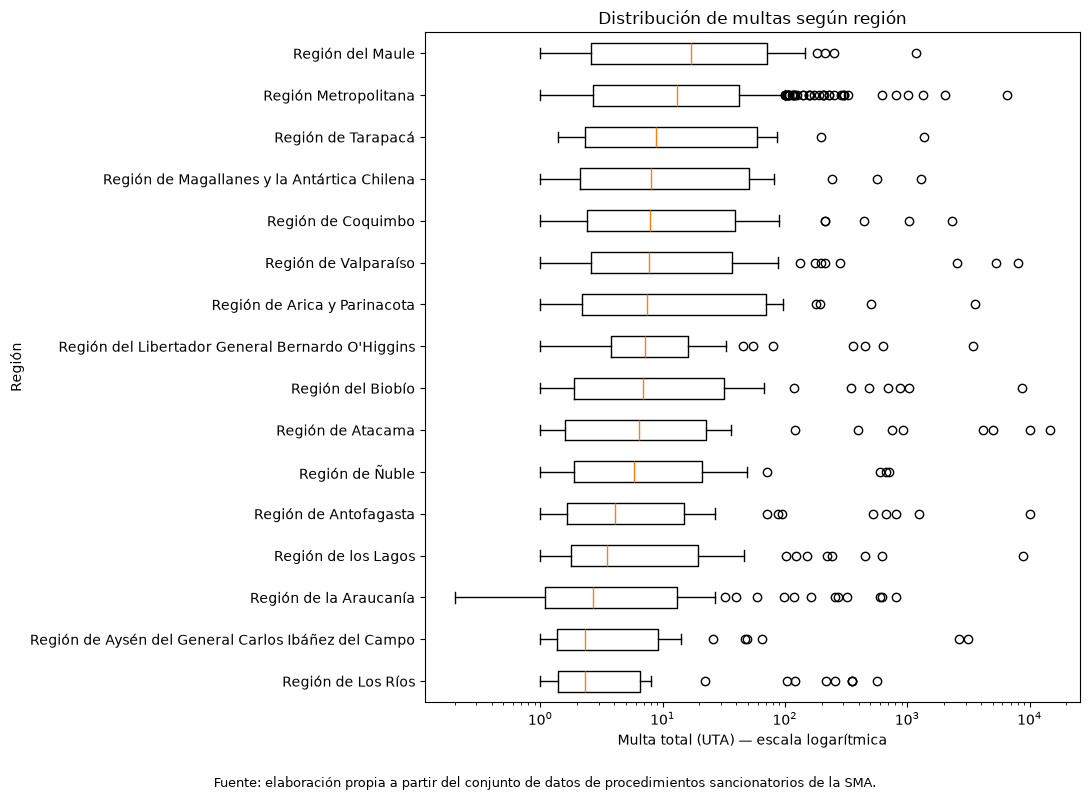

In [13]:
plt.figure(figsize=(11, 8))

plt.boxplot(
    [
        universo.loc[
            universo["RegionNombre"] == region,
            "MultaTotalUTA"
        ]
        for region in orden_region
    ],
    vert=False,
    tick_labels=orden_region
)

plt.xscale("log")

plt.xlabel("Multa total (UTA) — escala logarítmica")
plt.ylabel("Región")
plt.title("Distribución de multas según región")

plt.figtext(
    0.5,
    0.01,
    "Fuente: elaboración propia a partir del conjunto de datos de procedimientos sancionatorios de la SMA.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [14]:
resumen_region[["cantidad", "mediana", "q1", "q3"]]

,cantidad,mediana,q1,q3
RegionNombre,,,,
Región del Maule,44,17.15,2.575,70.75
Región Metropolitana,324,13.00,2.675,42.00
Región de Tarapacá,35,8.80,2.300,59.50
Región de Magallanes y la Antártica Chilena,17,8.00,2.100,50.40
Región de Coquimbo,50,7.90,2.425,38.75
Región de Valparaíso,49,7.70,2.600,37.10
Región de Arica y Parinacota,23,7.50,2.200,70.00
Región del Libertador General Bernardo O'Higgins,49,7.20,3.800,16.00
Región del Biobío,59,6.90,1.900,32.00


## 8. Análisis por tipo de proceso

Se analiza la magnitud de las multas según `ProcesoSancionTipoNombre`.

Debido a la asimetría de `MultaTotalUTA`, se utiliza la mediana como medida descriptiva principal. El tamaño de cada grupo (`n`) se incorpora en la visualización para contextualizar la comparación.

La categoría `Programa de Cumplimiento` presenta un único procedimiento, por lo que su valor se muestra como una observación individual y no permite caracterizar una distribución.

In [15]:
resumen_tipo = (
    universo
    .groupby("ProcesoSancionTipoNombre")["MultaTotalUTA"]
    .agg(
        cantidad="count",
        mediana="median",
        promedio="mean",
        minimo="min",
        maximo="max",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
    )
    .sort_values("mediana", ascending=False)
)

resumen_tipo

,cantidad,mediana,promedio,minimo,maximo,q1,q3
ProcesoSancionTipoNombre,,,,,,,
Programa de Cumplimiento,1,227.2,227.200000,227.2,227.2,227.2,227.2
Fiscalización,223,7.4,232.398879,0.2,14745.0,1.7,36.0
Denuncia,739,7.0,135.889229,1.0,10000.0,2.0,34.5


In [16]:
orden_tipo = (
    universo
    .groupby("ProcesoSancionTipoNombre")["MultaTotalUTA"]
    .median()
    .sort_values()
    .index
)

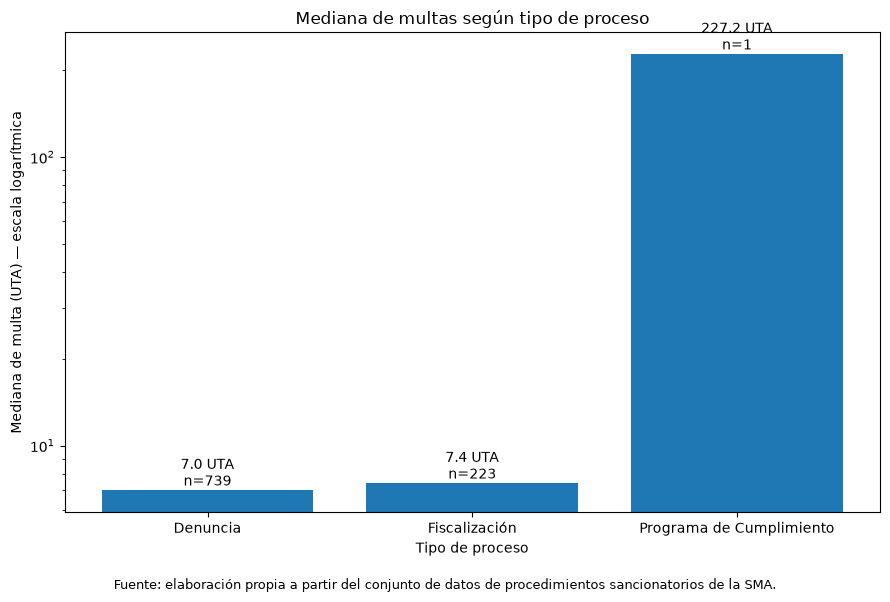

In [17]:
plt.figure(figsize=(9, 6))

datos_tipo = resumen_tipo.sort_values("mediana")

barras = plt.bar(
    datos_tipo.index,
    datos_tipo["mediana"]
)

plt.yscale("log")

plt.xlabel("Tipo de proceso")
plt.ylabel("Mediana de multa (UTA) — escala logarítmica")
plt.title("Mediana de multas según tipo de proceso")

for barra, mediana, cantidad in zip(
    barras,
    datos_tipo["mediana"],
    datos_tipo["cantidad"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        mediana,
        f"{mediana:.1f} UTA\nn={cantidad}",
        ha="center",
        va="bottom"
    )

plt.figtext(
    0.5,
    0.01,
    "Fuente: elaboración propia a partir del conjunto de datos de procedimientos sancionatorios de la SMA.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [18]:
resumen_tipo[["cantidad", "mediana", "q1", "q3"]]

,cantidad,mediana,q1,q3
ProcesoSancionTipoNombre,,,,
Programa de Cumplimiento,1,227.2,227.2,227.2
Fiscalización,223,7.4,1.7,36.0
Denuncia,739,7.0,2.0,34.5


# 9. Hallazgos

## 9.1 Hallazgos según rubro económico

La distribución de `MultaTotalUTA` presenta diferencias entre los rubros económicos. Debido a la marcada asimetría de la variable y a la presencia de valores extremos, la mediana y el rango intercuartílico se utilizan como medidas descriptivas principales.

La visualización en escala logarítmica permite comparar las distribuciones de los distintos rubros sin eliminar los valores extremos observados.

Los resultados deben interpretarse considerando el número de procedimientos disponibles en cada categoría. En particular, los rubros con pocos registros presentan mayor incertidumbre descriptiva.

## 9.2 Hallazgos según región

También se observan diferencias en la distribución de las multas entre regiones. Las regiones presentan diferentes medianas y niveles de dispersión, junto con valores extremos en varias categorías.

La cantidad de procedimientos por región es desigual, por lo que las diferencias descriptivas deben interpretarse considerando el tamaño de cada grupo.

## 9.3 Hallazgos según tipo de proceso

Las categorías Denuncia y Fiscalización presentan medianas de multa similares, de 7,0 y 7,4 UTA respectivamente.

Programa de Cumplimiento presenta un valor de 227,2 UTA; sin embargo, corresponde a un único procedimiento (`n=1`). Por esta razón, este valor no permite caracterizar la distribución de las multas para dicha categoría ni establecer una comparación equivalente con Denuncia y Fiscalización.

In [19]:
print("=== RUBRO ECONÓMICO ===")
print(
    resumen_rubro[
        ["cantidad", "mediana", "q1", "q3"]
    ].to_string()
)

print("\n=== REGIÓN ===")
print(
    resumen_region[
        ["cantidad", "mediana", "q1", "q3"]
    ].to_string()
)

=== RUBRO ECONÓMICO ===
                               cantidad  mediana      q1        q3
CategoriaEconomicaNombre                                          
Minería                              40    443.0  48.000  2403.750
Energía                              17    345.0  76.000   809.000
Infraestructura Hidráulica            2    135.0  77.500   192.500
Saneamiento Ambiental                27     91.0  23.000   234.700
Infraestructura de Transporte        10     52.0   8.275   119.300
Agroindustrias                       75     29.0   9.900    75.550
Vivienda e Inmobiliarios            150     27.0   3.775    62.000
Infraestructura Portuaria             8     21.6   4.150    93.750
Transportes y almacenajes             3     14.0   7.650   106.000
Instalación fabril                   47     11.0   2.050    67.500
Pesca y Acuicultura                  30     10.6   2.125    25.375
Otras categorías                     17      6.0   2.500    28.000
Forestal                             1

# 10. Síntesis de resultados

Los resultados muestran diferencias descriptivas en la magnitud de las multas según los tres factores analizados: rubro económico, región y tipo de proceso.

El rubro económico presenta diferencias particularmente marcadas. Minería registra una mediana de 443,0 UTA y Energía de 345,0 UTA, mientras que Equipamiento presenta una mediana de 3,1 UTA. Sin embargo, algunas categorías tienen pocos procedimientos, por lo que sus valores deben interpretarse con cautela.

También se observan diferencias entre regiones. La mediana alcanza 17,15 UTA en la Región del Maule y 13,0 UTA en la Región Metropolitana, mientras que regiones como Los Ríos y Aysén presentan medianas de 2,3 UTA. Estas diferencias son descriptivas y deben interpretarse considerando los distintos tamaños de los grupos.

En cuanto al tipo de proceso, Denuncia y Fiscalización presentan medianas similares, de 7,0 y 7,4 UTA respectivamente. Programa de Cumplimiento presenta 227,2 UTA, pero corresponde a un único procedimiento (`n=1`), por lo que no permite caracterizar el comportamiento de esa categoría.

En conjunto, los resultados sugieren que existen diferencias descriptivas en la magnitud de las multas asociadas al rubro económico y a la región. Para el tipo de proceso, las categorías con mayor cantidad de observaciones presentan distribuciones centrales similares.

# 11. Limitaciones

El análisis presenta algunas limitaciones que deben considerarse al interpretar los resultados.

- La distribución de `MultaTotalUTA` presenta una marcada asimetría positiva y valores extremos de gran magnitud.
- Los tamaños de los grupos son diferentes entre rubros, regiones y tipos de proceso.
- Algunas categorías presentan muy pocos procedimientos. Por ejemplo, Infraestructura Hidráulica tiene `n=2` y Programa de Cumplimiento tiene `n=1`.
- El análisis realizado es descriptivo y permite identificar diferencias y patrones de asociación, pero no permite establecer relaciones causales.
- La consolidación a nivel de `ProcesoSancionId` evita contabilizar repetidamente una misma multa cuando un procedimiento está asociado a más de una unidad fiscalizable.
- Los valores extremos fueron conservados porque corresponden a observaciones presentes en el conjunto de datos y pueden representar sanciones reales de elevada magnitud.

# 12. Conclusiones

El análisis del universo de 963 procedimientos sancionatorios muestra diferencias descriptivas en la magnitud de las multas según el rubro económico y la región.

El rubro económico presenta las diferencias más marcadas en las medianas observadas. Minería y Energía presentan valores centrales considerablemente superiores a categorías como Equipamiento, aunque el tamaño de los grupos debe considerarse al interpretar estas diferencias.

También existen diferencias entre regiones, con medianas que varían desde 2,3 UTA hasta 17,15 UTA en el conjunto analizado.

En el caso del tipo de proceso, Denuncia y Fiscalización presentan valores centrales similares. El único procedimiento clasificado como Programa de Cumplimiento presenta una multa de 227,2 UTA, pero su tamaño muestral impide utilizarlo para caracterizar una distribución.

Por lo tanto, los resultados permiten identificar diferencias descriptivas asociadas al rubro económico y a la región, mientras que para establecer asociaciones más robustas sería necesario complementar este análisis descriptivo con métodos estadísticos o modelos que consideren simultáneamente las variables relevantes y el efecto de los tamaños de grupo.